In [1]:
#Importing Libraries
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import logit as sp_logit, expit as sigmoid
from scipy.optimize import minimize_scalar
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

BG    = "white"
ACC1  = "#5c6bc0"   # indigo  
ACC2  = "#00897b"   # teal   
WARN  = "#e53935"   # red     
IDEAL = "#f57f17"   # amber  

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "font.size": 11})

In [2]:
PROJECT_ROOT = os.getcwd()

DATA_PATH    = os.path.join(PROJECT_ROOT, "planetsdata.csv")
RANDOM_STATE = 42
TARGET       = "P_HABITABLE_BINARY"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from train_unified_pipeline import prepare_dataframe, build_unified_pipeline

# Load dataset
df = prepare_dataframe(DATA_PATH)

X = df.drop(columns=[TARGET, "P_NAME"], errors="ignore")
y = df[TARGET]
numerical_cols   = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# Three-way split:  60 % train | 20 % calibration | 20 % test 
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,          # 0.25 × 0.80 = 0.20 of total  → 60/20/20
    random_state=RANDOM_STATE, stratify=y_trainval
)

print(f"\n{'Split':<15}  {'Samples':>8}  {'Positive %':>10}")
for name, y_ in [("Train (RF)", y_tr), ("Calibration", y_cal), ("Test", y_test)]:
    print(f"{name:<15}  {len(y_):>8,}  {y_.mean()*100:>9.2f} %")


Raw data shape: (5569, 118)
Cleaned data shape: (5569, 32)
Class distribution:
P_HABITABLE_BINARY
0    5500
1      69
Name: count, dtype: int64

Split             Samples  Positive %
Train (RF)          3,341       1.23 %
Calibration         1,114       1.26 %
Test                1,114       1.26 %


In [3]:
# Fit the pipeline on the 60 % training split 
# We re-train so X_cal and X_test are genuinely unseen during
# RF training — required for honest calibration evaluation.

pipeline = build_unified_pipeline(numerical_cols, categorical_cols, use_smote=True)
pipeline.fit(X_tr, y_tr)
print("Pipeline fitted:", [name for name, _ in pipeline.steps])

# Raw (uncalibrated) probability predictions
p_raw_cal  = pipeline.predict_proba(X_cal)[:, 1]   # calibration → fit T
p_raw_test = pipeline.predict_proba(X_test)[:, 1]  # test        → evaluate

print(f"\nRaw test-set probabilities:")
print(f"  Shape : {p_raw_test.shape}")
print(f"  Min   : {p_raw_test.min():.4f}   Max  : {p_raw_test.max():.4f}")
print(f"  Mean  : {p_raw_test.mean():.4f}  Std  : {p_raw_test.std():.4f}")


Pipeline fitted: ['preprocessor', 'smote', 'classifier']

Raw test-set probabilities:
  Shape : (1114,)
  Min   : 0.0000   Max  : 0.9884
  Mean  : 0.0199  Std  : 0.1109


In [4]:
# Calibration helper functions

def compute_ece(y_true, y_prob, n_bins=10):
    '''
    Expected Calibration Error (ECE) with equal-width bins.
    ECE = sum_b (n_b / n) * |accuracy_b - confidence_b|
    Returns (ece_float, list_of_bin_dicts)
    '''
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    edges  = np.linspace(0.0, 1.0, n_bins + 1)
    n      = len(y_true)
    ece    = 0.0
    records = []

    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        acc  = float(y_true[mask].mean())
        conf = float(y_prob[mask].mean())
        frac = mask.sum() / n
        ece  += frac * abs(acc - conf)
        records.append({
            "lo": lo, "hi": hi, "mid": (lo + hi) / 2,
            "acc": acc, "conf": conf, "frac": frac, "n": int(mask.sum()),
        })
    return ece, records


def draw_reliability_diagram(ax_diag, ax_hist, y_true, y_prob,
                             color, label, n_bins=10):
    '''
    Draw reliability curve + gap shading + confidence histogram.
    Returns the ECE value.
    '''
    prob_true, prob_pred = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy="uniform"
    )
    ece, records = compute_ece(y_true, y_prob, n_bins=n_bins)

    # Perfect diagonal
    ax_diag.plot([0, 1], [0, 1], "--", color=IDEAL, lw=1.5,
                 label="Perfect calibration", zorder=1)

    # Shaded gap area between curve and diagonal
    ax_diag.fill_between(prob_pred, prob_pred, prob_true,
                         alpha=0.13, color=WARN, zorder=2)

    # Per-bin gap bars
    for r in records:
        lo_bar = min(r["conf"], r["acc"])
        height = abs(r["acc"] - r["conf"])
        ax_diag.bar(r["mid"], height, bottom=lo_bar,
                    width=0.075, color=WARN, alpha=0.22, zorder=2, linewidth=0)

    # Reliability curve
    ax_diag.plot(prob_pred, prob_true, "o-", color=color, lw=2.2, ms=7,
                 label=f"{label}  (ECE = {ece:.4f})", zorder=3)

    ax_diag.set_xlim(-0.02, 1.02)
    ax_diag.set_ylim(-0.02, 1.02)
    ax_diag.set_xlabel("Mean predicted probability")
    ax_diag.set_ylabel("Fraction of positives")
    ax_diag.legend(fontsize=9, loc="lower right")
    ax_diag.grid(True, alpha=0.4)

    # Confidence histogram (distribution of predictions)
    ax_hist.hist(y_prob, bins=25, range=(0, 1),
                 color=color, alpha=0.72, edgecolor=BG)
    ax_hist.axvline(0.5, color=IDEAL, ls="--", lw=1.2, label="Threshold 0.5")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title("Confidence Histogram", fontsize=10, color="#555555")
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    return ece

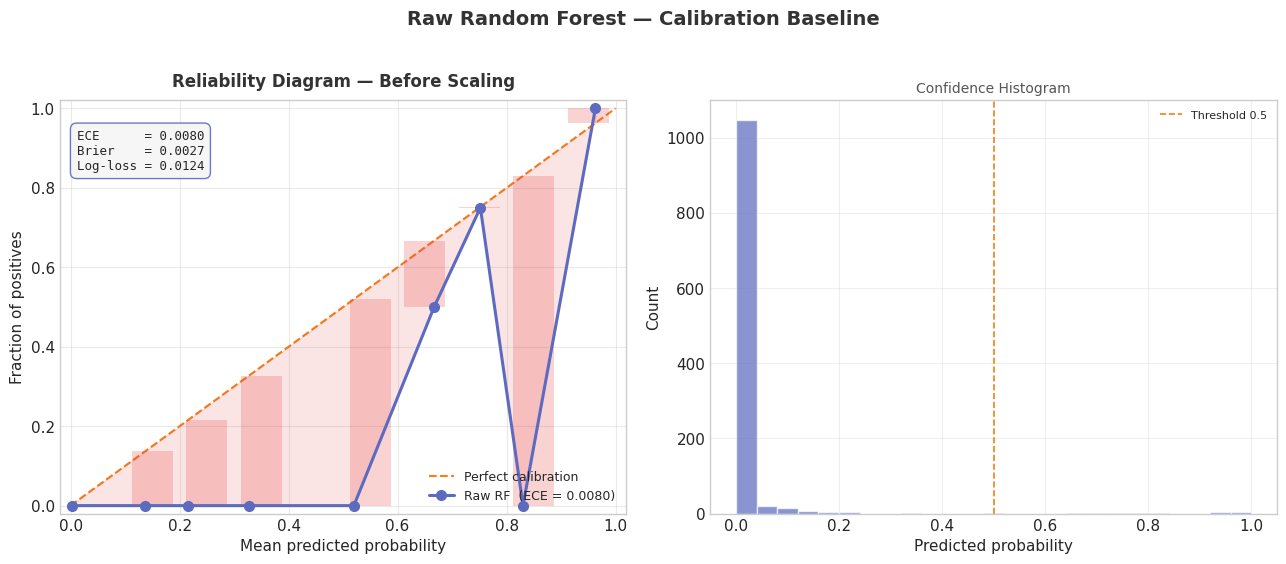

  BASELINE METRICS  (Raw Random Forest)
  ECE         : 0.0080
  Brier Score : 0.0027
  Log-loss    : 0.0124


In [5]:
# Reliability Diagram — BEFORE Temperature Scaling
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("Raw Random Forest — Calibration Baseline",
             fontsize=14, fontweight="bold", color="#333333", y=1.02)

ece_raw = draw_reliability_diagram(
    axes[0], axes[1], 
    y_test.values, p_raw_test, color=ACC1, label="Raw RF"
)
axes[0].set_title("Reliability Diagram — Before Scaling",
                  fontsize=12, fontweight="bold", color="#333333", pad=10)

brier_raw   = brier_score_loss(y_test, p_raw_test)
logloss_raw = log_loss(y_test, p_raw_test)

axes[0].text(
    0.03, 0.93,
    f"ECE      = {ece_raw:.4f}\nBrier    = {brier_raw:.4f}\nLog-loss = {logloss_raw:.4f}",
    transform=axes[0].transAxes, fontsize=9,
    verticalalignment="top", fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor=ACC1, alpha=0.9)
)

plt.tight_layout()
plt.show()

print("  BASELINE METRICS  (Raw Random Forest)")
print(f"  ECE         : {ece_raw:.4f}")
print(f"  Brier Score : {brier_raw:.4f}")
print(f"  Log-loss    : {logloss_raw:.4f}")

  TEMPERATURE SEARCH RESULT
  Optimal T            : 0.4498
  NLL at T=1  (raw)    : 0.0116
  NLL at T_opt (cal'd) : 0.0061
Scaling will sharpen probabilities toward 0 and 1


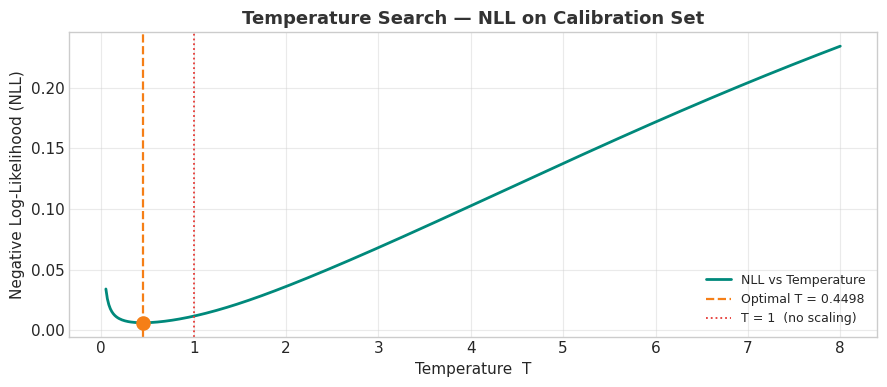

In [6]:
# Temperature Scaling implementation 

def apply_temperature(probs, T):
    '''Calibrate: sigmoid( logit(p) / T ).'''
    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    return sigmoid(sp_logit(probs) / T)


def nll(T, probs, labels):
    '''Negative log-likelihood — the optimisation objective.'''
    p = np.clip(apply_temperature(probs, T), 1e-9, 1 - 1e-9)
    return -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))


# Scan T, then fine-tune with scipy bounded minimisation 
T_grid   = np.linspace(0.05, 8.0, 500)
nll_grid = [nll(T, p_raw_cal, y_cal.values) for T in T_grid]

result = minimize_scalar(
    nll, bounds=(0.05, 10.0), method="bounded",
    args=(p_raw_cal, y_cal.values),
    options={"xatol": 1e-7},
)
T_opt = result.x

print("  TEMPERATURE SEARCH RESULT")
print(f"  Optimal T            : {T_opt:.4f}")
print(f"  NLL at T=1  (raw)    : {nll(1.0,   p_raw_cal, y_cal.values):.4f}")
print(f"  NLL at T_opt (cal'd) : {nll(T_opt, p_raw_cal, y_cal.values):.4f}")

if T_opt > 1.05:
    print(f"Scaling will compress probabilities toward 0.5")
elif T_opt < 0.95:
    print(f"Scaling will sharpen probabilities toward 0 and 1")
else:
    print(f"\nT ≈ 1 : Random Forest is already well-calibrated!")

# NLL curve plot 
fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
ax.plot(T_grid, nll_grid, color=ACC2, lw=2.0, label="NLL vs Temperature")
ax.axvline(T_opt, color=IDEAL, ls="--", lw=1.6, label=f"Optimal T = {T_opt:.4f}")
ax.axvline(1.0,   color=WARN,  ls=":",  lw=1.3, label="T = 1  (no scaling)")
ax.scatter([T_opt], [nll(T_opt, p_raw_cal, y_cal.values)],
           color=IDEAL, s=90, zorder=5)
ax.set_xlabel("Temperature  T")
ax.set_ylabel("Negative Log-Likelihood (NLL)")
ax.set_title("Temperature Search — NLL on Calibration Set",
             fontsize=13, fontweight="bold", color="#333333")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [7]:
# Apply Temperature Scaling to the TEST set
p_cal_test = apply_temperature(p_raw_test, T_opt)

print(f"Applied Temperature Scaling  (T = {T_opt:.4f})  to {len(p_cal_test):,} test samples")
print()

df_peek = pd.DataFrame({
    "True Label"      : y_test.values[:14],
    "Raw Prob"        : np.round(p_raw_test[:14], 4),
    "Calibrated Prob" : np.round(p_cal_test[:14], 4),
    "Delta"           : np.round(p_cal_test[:14] - p_raw_test[:14], 4),
})
print(df_peek.to_string(index=False))
print()
print(f"  Mean before scaling : {p_raw_test.mean():.4f}  |  Std: {p_raw_test.std():.4f}")
print(f"  Mean after  scaling : {p_cal_test.mean():.4f}  |  Std: {p_cal_test.std():.4f}")


Applied Temperature Scaling  (T = 0.4498)  to 1,114 test samples

 True Label  Raw Prob  Calibrated Prob   Delta
          0    0.0000           0.0000  0.0000
          0    0.0069           0.0000 -0.0069
          0    0.0000           0.0000  0.0000
          0    0.0135           0.0001 -0.0134
          0    0.1183           0.0114 -0.1069
          0    0.0000           0.0000  0.0000
          0    0.0000           0.0000  0.0000
          0    0.0000           0.0000  0.0000
          0    0.0160           0.0001 -0.0159
          0    0.0000           0.0000  0.0000
          0    0.0002           0.0000 -0.0002
          0    0.1495           0.0205 -0.1290
          0    0.1884           0.0374 -0.1510
          0    0.0000           0.0000  0.0000

  Mean before scaling : 0.0199  |  Std: 0.1109
  Mean after  scaling : 0.0158  |  Std: 0.1188


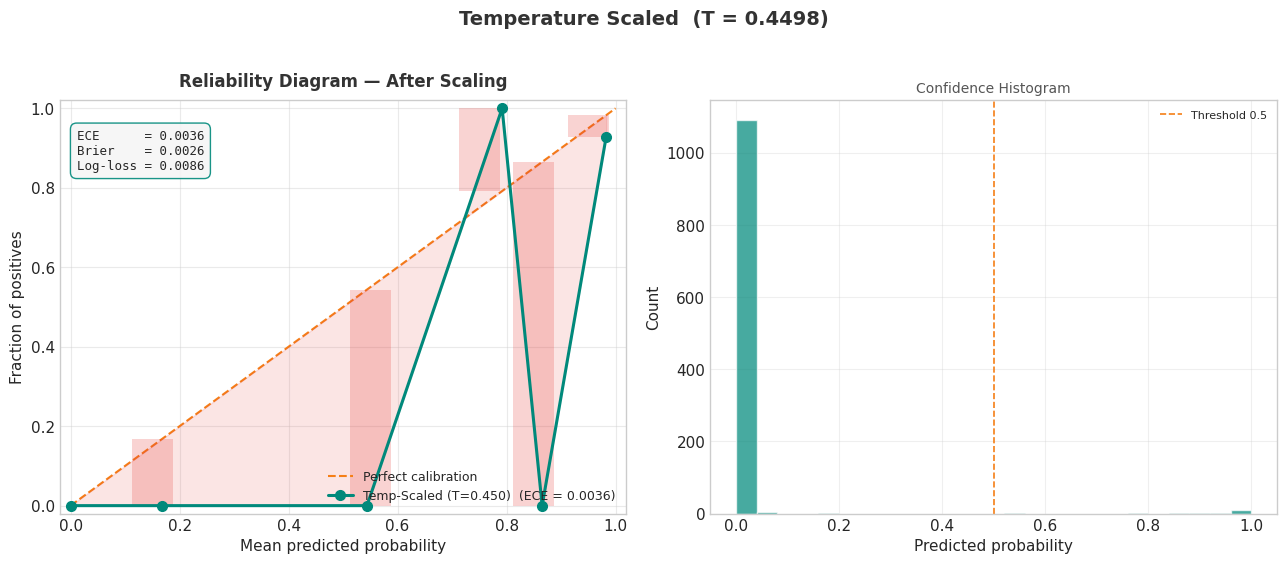

  POST-CALIBRATION METRICS  (Temp-Scaled)
  ECE         : 0.0036
  Brier Score : 0.0026
  Log-loss    : 0.0086


In [8]:
# Reliability Diagram — AFTER Temperature Scaling
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)
fig.suptitle(f"Temperature Scaled  (T = {T_opt:.4f})",
             fontsize=14, fontweight="bold", color="#333333", y=1.02)

ece_cal = draw_reliability_diagram(
    axes[0], axes[1],
    y_test.values, p_cal_test,
    color=ACC2, label=f"Temp-Scaled (T={T_opt:.3f})"
)
axes[0].set_title("Reliability Diagram — After Scaling",
                  fontsize=12, fontweight="bold", color="#333333", pad=10)

brier_cal   = brier_score_loss(y_test, p_cal_test)
logloss_cal = log_loss(y_test, p_cal_test)

axes[0].text(
    0.03, 0.93,
    f"ECE      = {ece_cal:.4f}\nBrier    = {brier_cal:.4f}\nLog-loss = {logloss_cal:.4f}",
    transform=axes[0].transAxes, fontsize=9,
    verticalalignment="top", fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor=ACC2, alpha=0.9)
)

plt.tight_layout()
plt.show()

print("  POST-CALIBRATION METRICS  (Temp-Scaled)")
print(f"  ECE         : {ece_cal:.4f}")
print(f"  Brier Score : {brier_cal:.4f}")
print(f"  Log-loss    : {logloss_cal:.4f}")
print("=" * 52)


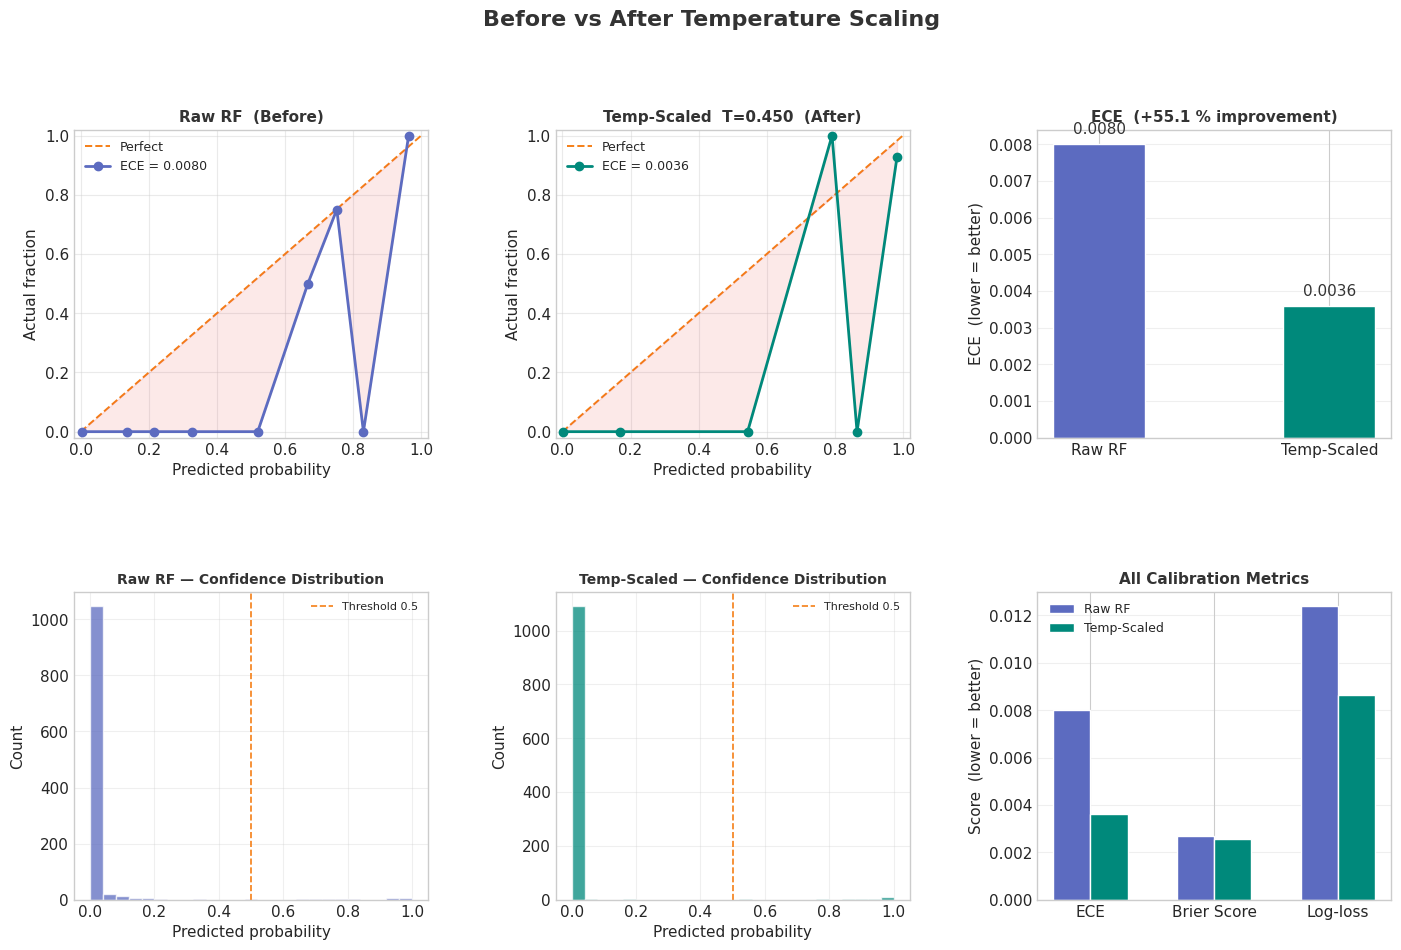

In [9]:
# Full 2 × 3 comparison figure 
fig = plt.figure(figsize=(17, 10), facecolor=BG)
fig.suptitle("Before vs After Temperature Scaling",
             fontsize=16, fontweight="bold", color="#333333", y=1.00)

gs = fig.add_gridspec(2, 3, hspace=0.50, wspace=0.36)

# Top row: reliability curves + ECE bar
for ci, (probs, color, title) in enumerate([
    (p_raw_test, ACC1, "Raw RF  (Before)"),
    (p_cal_test, ACC2, f"Temp-Scaled  T={T_opt:.3f}  (After)"),
]):
    ax = fig.add_subplot(gs[0, ci])
    pt, pp = calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    ev = compute_ece(y_test.values, probs)[0]
    ax.plot([0, 1], [0, 1], "--", color=IDEAL, lw=1.4, label="Perfect", zorder=1)
    ax.fill_between(pp, pp, pt, alpha=0.11, color=WARN, zorder=2)
    ax.plot(pp, pt, "o-", color=color, lw=2.0, ms=6,
            label=f"ECE = {ev:.4f}", zorder=3)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Predicted probability"); ax.set_ylabel("Actual fraction")
    ax.set_title(title, fontsize=11, fontweight="bold", color="#333333")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

# ECE improvement bar
ax_ece = fig.add_subplot(gs[0, 2])
ece_vals = [ece_raw, ece_cal]
bars = ax_ece.bar(["Raw RF", "Temp-Scaled"], ece_vals,
                  color=[ACC1, ACC2], width=0.4, edgecolor=BG)
for b, v in zip(bars, ece_vals):
    ax_ece.text(b.get_x() + b.get_width() / 2, v + 0.0002,
                f"{v:.4f}", ha="center", va="bottom", fontsize=11, color="#333333")
delta_pct = (ece_raw - ece_cal) / ece_raw * 100
ax_ece.set_title(f"ECE  ({delta_pct:+.1f} % improvement)",
                 fontsize=11, fontweight="bold", color="#333333")
ax_ece.set_ylabel("ECE  (lower = better)"); ax_ece.grid(True, alpha=0.3, axis="y")

# Bottom row: confidence histograms + grouped metric bars 
for ci, (probs, color, title) in enumerate([
    (p_raw_test, ACC1, "Raw RF — Confidence Distribution"),
    (p_cal_test, ACC2, "Temp-Scaled — Confidence Distribution"),
]):
    ax = fig.add_subplot(gs[1, ci])
    ax.hist(probs, bins=25, range=(0, 1), color=color, alpha=0.75, edgecolor=BG)
    ax.axvline(0.5, color=IDEAL, ls="--", lw=1.2, label="Threshold 0.5")
    ax.set_xlabel("Predicted probability"); ax.set_ylabel("Count")
    ax.set_title(title, fontsize=10, fontweight="bold", color="#333333")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Grouped metric bars
ax_all = fig.add_subplot(gs[1, 2])
metric_names = ["ECE", "Brier Score", "Log-loss"]
raw_vals_all = [ece_raw, brier_raw, logloss_raw]
cal_vals_all = [ece_cal, brier_cal, logloss_cal]
x = np.arange(len(metric_names))
w = 0.30
ax_all.bar(x - w / 2, raw_vals_all, w, color=ACC1, label="Raw RF",      edgecolor=BG)
ax_all.bar(x + w / 2, cal_vals_all, w, color=ACC2, label="Temp-Scaled", edgecolor=BG)
ax_all.set_xticks(x); ax_all.set_xticklabels(metric_names)
ax_all.set_ylabel("Score  (lower = better)")
ax_all.set_title("All Calibration Metrics", fontsize=11,
                 fontweight="bold", color="#333333")
ax_all.legend(fontsize=9); ax_all.grid(True, alpha=0.3, axis="y")
plt.show()

In [10]:
# Summary Table 
roc_raw = roc_auc_score(y_test, p_raw_test)
roc_cal = roc_auc_score(y_test, p_cal_test)   # rank-preserving → stays the same

def pct_imp(before, after):
    return f"{(before - after) / abs(before) * 100:+.1f} %"

summary = pd.DataFrame({
    "Metric": [
        "ECE  (lower = better)",
        "Brier Score  (lower = better)",
        "Log-loss  (lower = better)",
        "ROC-AUC  (higher = better)",
    ],
    "Raw RF": [
        f"{ece_raw:.4f}",
        f"{brier_raw:.4f}",
        f"{logloss_raw:.4f}",
        f"{roc_raw:.4f}",
    ],
    "Temp-Scaled": [
        f"{ece_cal:.4f}",
        f"{brier_cal:.4f}",
        f"{logloss_cal:.4f}",
        f"{roc_cal:.4f}",
    ],
    "Improvement": [
        pct_imp(ece_raw, ece_cal),
        pct_imp(brier_raw, brier_cal),
        pct_imp(logloss_raw, logloss_cal),
        "unchanged (by design)",
    ],
})

print("Temperature Scaling Calibration Report")
print(summary.to_string(index=False))
print(f"\n  Optimal Temperature T  = {T_opt:.4f}")
print(f"  Calibration set size   = {len(y_cal):,} samples")
print(f"  Test set size          = {len(y_test):,} samples")


Temperature Scaling Calibration Report
                       Metric Raw RF Temp-Scaled           Improvement
        ECE  (lower = better) 0.0080      0.0036               +55.1 %
Brier Score  (lower = better) 0.0027      0.0026                +5.4 %
   Log-loss  (lower = better) 0.0124      0.0086               +30.4 %
   ROC-AUC  (higher = better) 0.9996      0.9996 unchanged (by design)

  Optimal Temperature T  = 0.4498
  Calibration set size   = 1,114 samples
  Test set size          = 1,114 samples
